In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [29]:
data = pd.read_excel('data/Pyrolysis_Data 6-16_Reduced.xlsx')

data.describe()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,6669,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,...,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000
mean,2015-12-22 07:16:59.470808576,52086.607262,8712.582010,8287.932362,8842.522833,8603.680748,8444.248226,8865.866092,4297.905730,4452.905547,...,617.811929,622.511101,831.648208,836.780286,835.400132,836.319523,837.300782,837.903612,1027.474983,837.910011
min,2015-11-06 00:00:00,45736.531250,7466.118164,7110.184570,7652.420410,7561.086914,7439.499512,7731.586426,4147.067871,4204.664050,...,603.491333,611.425110,804.398743,809.329590,810.840485,812.086029,811.762329,811.068130,980.803802,813.534363
25%,2015-11-29 03:40:00.007000064,52080.425781,8674.464844,8250.759766,8816.666992,8557.800781,8409.102539,8819.564453,4277.095703,4445.440693,...,614.694580,620.329590,830.853425,836.122177,834.470825,835.493164,836.341479,836.836578,1019.737488,837.743379
50%,2015-12-22 07:19:27.335000064,52136.097656,8731.911133,8286.455078,8849.289062,8605.119141,8459.644902,8884.833008,4288.175293,4462.412109,...,618.976257,622.934143,831.628510,836.826157,835.474991,836.345734,837.407837,838.015167,1029.567841,837.979076
75%,2016-01-14 10:54:36.375000064,52197.140625,8777.038086,8320.266851,8883.692383,8672.966798,8504.736328,8927.785156,4300.790039,4474.368161,...,620.939880,624.776917,832.425751,837.532196,836.445328,837.252701,838.400406,839.075317,1035.154907,838.240967
max,2016-02-06 14:25:05.950000,53489.472656,9053.129883,9278.496829,9080.204688,8854.346362,8805.973330,9129.166016,4469.789062,4630.651488,...,625.199951,629.285583,846.023840,865.560687,845.728282,843.780106,846.446014,850.595634,1045.856140,841.106018
std,NaN,464.738337,121.623591,120.638306,95.786130,107.469695,112.196548,106.172983,40.376338,42.363111,...,3.940449,2.917192,1.910854,2.236806,1.922875,1.811575,2.094034,2.244648,10.038618,1.285605


In [ ]:
def plot_data(X, y, x_name, y_name, time = None, k = None):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    if time is not None:
        norm = TwoSlopeNorm(vmin=min(time), vcenter=np.mean(time), vmax=max(time))
        colors = [plt.cm.jet(norm(c)) for c in time]

    axs0.scatter(X, y, color = 'none', marker = 'o', edgecolors=colors, linewidth=1)

    if k is None:
        axs0.text(9000, 8000, s = 'All data', fontsize='x-large')
    else:
        axs0.text(9000, 8000, s = f'k = {k}', fontsize='x-large')

    axs0.set_xlabel(f'{x_name}', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(f'{y_name}', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    cbaxes = inset_axes(axs0, width="30%", height="3%", loc='upper right')

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.jet), cax=cbaxes, shrink = 0.7, aspect = 30, orientation = 'horizontal')#, pad = 1)
    
    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Time$', fontsize = 'x-large')
    cb.ax.tick_params(size=0)
    cb.set_ticks([])

    axs0.set_xlim(7250, 9500)
    axs0.set_ylim(7700, 9500)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

In [ ]:
def plot_data_ts(X, y, x_name, y_name, time = None, k = None):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)
    axs1 = axs0.twinx()

    if time is not None:
        norm = TwoSlopeNorm(vmin=min(time), vcenter=np.mean(time), vmax=max(time))
        colors = [plt.cm.jet(norm(c)) for c in time]

    axs0.scatter(time, y, color = 'none', marker = 's', edgecolors=colors, linewidth=1)
    
    axs1.scatter(time, X, color = 'none', marker = 'o', edgecolors=colors, linewidth=1)

    if k is None:
        axs0.text(1.44676800e+09, 7500, s = 'All data', fontsize='x-large')
    else:
        axs0.text(1.44676800e+09, 7500, s = f'k = {k}', fontsize='x-large')

    axs0.set_ylabel(f'{y_name}', labelpad = 10, fontsize='x-large')
    axs1.set_ylabel(f'{x_name}', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    axs1.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs1.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)
        axs1.spines[ax].set_linewidth(1)

    cbaxes = inset_axes(axs0, width="30%", height="3%", loc='upper right')

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.jet), cax=cbaxes, shrink = 0.7, aspect = 30, orientation = 'horizontal')#, pad = 1)

    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Time$', fontsize = 'x-large')
    cb.ax.tick_params(size=0)
    cb.set_ticks([])

    axs0.set_ylim(7000, 9500)
    axs1.set_ylim(7000, 9500)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

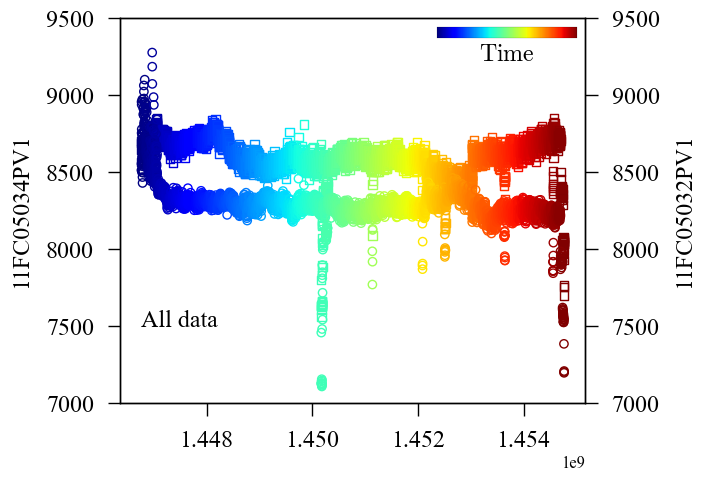

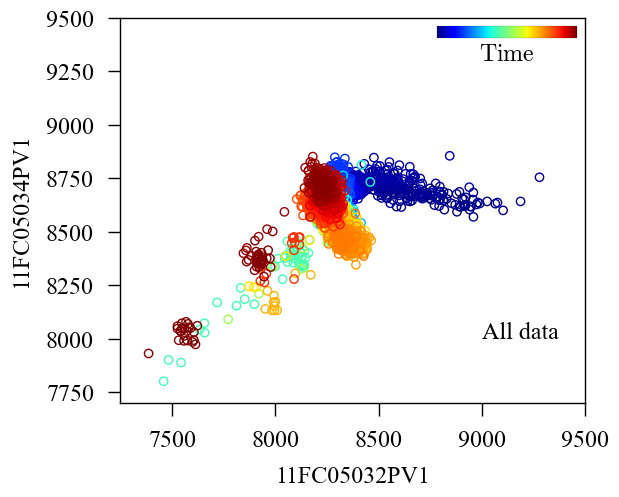

In [30]:
X = "11FC05032PV1"
y = "11FC05034PV1"

plot_data_ts(data.iloc[:, data.columns.get_loc(X)], data.iloc[:, data.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data.iloc[:, 0]]))
plot_data(data.iloc[:, data.columns.get_loc(X)], data.iloc[:, data.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data.iloc[:, 0]]))

In [ ]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

def get_threshold(training_data, k = 5):
        """
        It takes in a training data set, computes the kNN distance, sorts the distances, and then finds the
        knee point of the sorted distances. 
        
        The knee point is the point where the curve changes from being linear to being exponential. 
            
        :param training_data: the data that we want to find the threshold for
        :return: The distances, the threshold, and the nbrs
        """

        nbrs = NearestNeighbors(n_neighbors = k).fit(training_data)
        distances, indices = nbrs.kneighbors(training_data)

        distances = distances.flatten()

        kneedle = KneeLocator(np.indices(distances.shape)[0], distances, S=200, curve="concave", direction="increasing")#, online=True)

        threshold = kneedle.elbow_y
        
        return distances, threshold, nbrs

In [23]:
def plot_elbow(distances, threshold, name = 'elbow'):
    
    fig1 = plt.figure(figsize=(6, 5))

    axs1 = fig1.add_subplot(111)

    distances = np.sort(distances[distances != 0])
    
    axs1.plot(
            distances, 
            color = 'purple', 
            linewidth = 2)

    axs1.plot(
            [0, len(distances)], 
            [threshold, threshold], 
            color = 'r', 
            linestyle = '--', 
            linewidth = 2,
            label = 'knn distance threshold')


    axs1.set_xlabel(r'$\rm Sample$', labelpad=5, fontsize='x-large')
    axs1.set_ylabel(r'$\rm kNN\ distance$', labelpad=5, fontsize='x-large')

    axs1.legend(frameon=False, ncol=2)
    
    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                        ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.legend(frameon = False, ncol=2, fontsize = 'small')
    plt.tight_layout()

    plt.savefig('figures/example-2-2.png', dpi = 300)

    plt.show()

    return None


In [ ]:
def ood(x, nbrs, threshold):
        """
        > If the maximum distance between the input and its nearest neighbors is greater than twice the
        threshold, then the input is considered out of distribution
        
        :param x: the data point we want to classify
        :param nbrs: the kNN model
        :param threshold: the threshold for the distance to the nearest neighbor. If the distance is
        greater than 2*threshold, then the point is considered out of distribution
        :return: a boolean value and the distance.
        """

        
        out_of_distribution = False

        distances, indices = nbrs.kneighbors(x.reshape(1, -1))

        distance = max(distances[0])

        if distance > threshold:
                out_of_distribution = True

        return out_of_distribution

In [10]:
distances, threshold, nbrs = get_threshold(data.iloc[:, 1:], k=10)

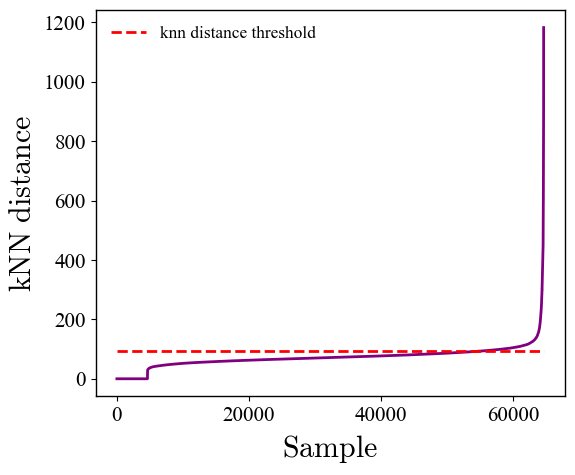

In [25]:
plot_elbow(distances, threshold)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def remove_outliers(data, k):

    distances, threshold, nbrs = get_threshold(data.iloc[:, 1:], k)

    for index, row in data.iloc[:, 1:].iterrows():
        if ood(np.asarray(row), nbrs=nbrs, threshold=threshold):
            data = data.drop(index)

    return data

data_no_outliers = remove_outliers(data, k=10)

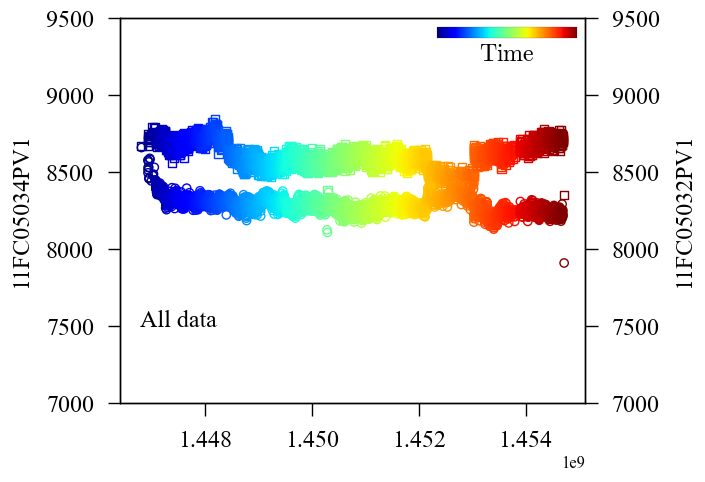

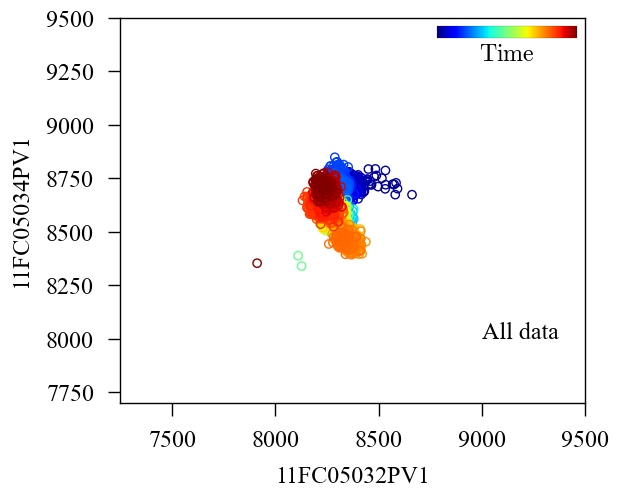

In [28]:
plot_data_ts(data_no_outliers.iloc[:, data_no_outliers.columns.get_loc(X)], data_no_outliers.iloc[:, data_no_outliers.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data_no_outliers.iloc[:, 0]]))
plot_data(data_no_outliers.iloc[:, data_no_outliers.columns.get_loc(X)], data_no_outliers.iloc[:, data_no_outliers.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data_no_outliers.iloc[:, 0]]))